# Week 2 - Day 5 - Hands On Lab
Complete EDA Notebook (Full Week 2 Summary): Medical Insurance Charges

### Objective

This notebook brings together everything from Week 2 into one complete, narrated Exploratory Data Analysis: descriptive statistics (Day 1), univariate distributions and outlier handling (Day 4), and bivariate relationships and correlation (Day 5) - all on the same real dataset.

Dataset: Medical Cost Personal Dataset (Kaggle) - data/insurance.csv, 1,337 records after removing 1 duplicate.

---

### Import Libraries

In [162]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

---

### Load and Prepare the Data

In [163]:
df = pd.read_csv("data/insurance.csv")
df = df.drop_duplicates()

print("Shape:", df.shape)
df.head()

Shape: (1337, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---

### Part 1: Descriptive Statistics (Day 1 Recap)

I'm starting with the same measure I focused on in Day 1 - charges - since it's the most important column in this dataset.

In [164]:
charges = df["charges"]

mean_val = np.mean(charges)
median_val = np.median(charges)
std_val = np.std(charges)
q1, q3 = np.percentile(charges, [25, 75])
iqr = q3 - q1

print("Mean:", round(mean_val, 2))
print("Median:", round(median_val, 2))
print("Standard Deviation:", round(std_val, 2))
print("IQR:", round(iqr, 2))

Mean: 13279.12
Median: 9386.16
Standard Deviation: 12105.83
IQR: 11911.37


**What this tells me:** 
the mean is about $3,900 higher than the median - charges is right-skewed, meaning a smaller group of patients has unusually high costs pulling the average up.

---

### Part 2: Univariate Analysis & Outliers (Day 4 Recap)

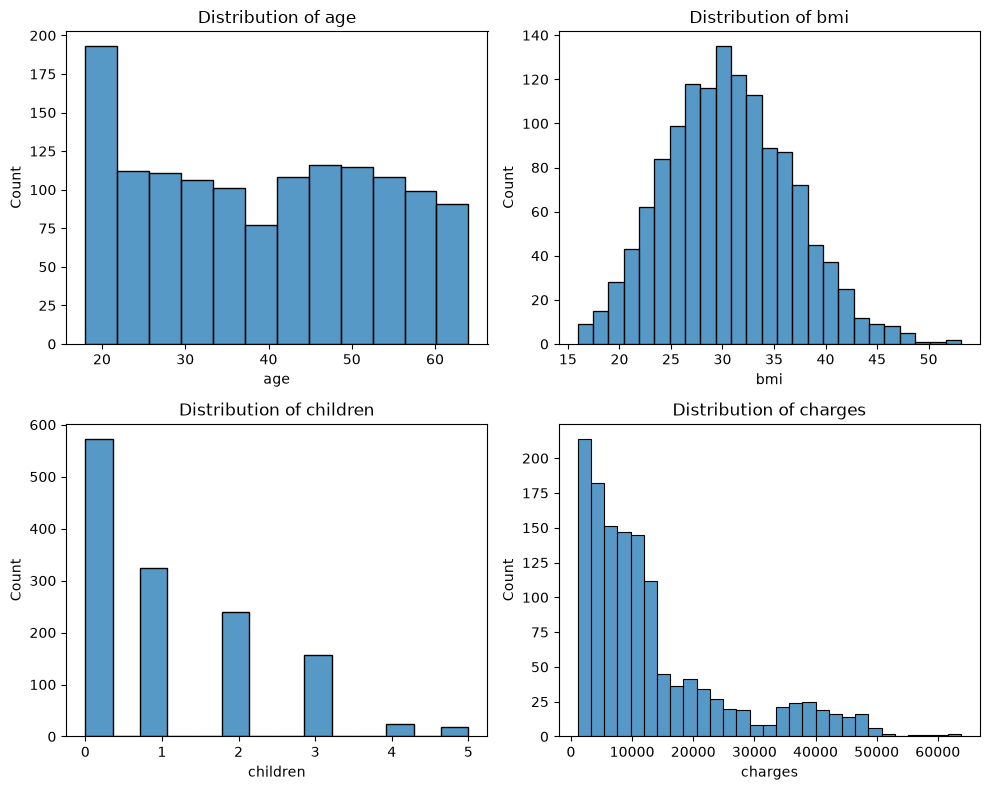

In [165]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flatten(), ["age", "bmi", "children", "charges"]):
    sns.histplot(data=df, x=col, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

**What this shows:**
 age and bmi look roughly normal. charges is heavily right-skewed, matching Part 1.

In [166]:
Q1 = df["charges"].quantile(0.25)
Q3 = df["charges"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["charges"] < lower_bound) | (df["charges"] > upper_bound)]
print("Number of outliers in charges:", len(outliers))
print(outliers["smoker"].value_counts())

Number of outliers in charges: 139
smoker
yes    136
no       3
Name: count, dtype: int64


**What this tells me:** 98% of the outliers are smokers, even though smokers are only about 20% of the dataset. I decided to keep these outliers - they're a real pattern, not data errors.

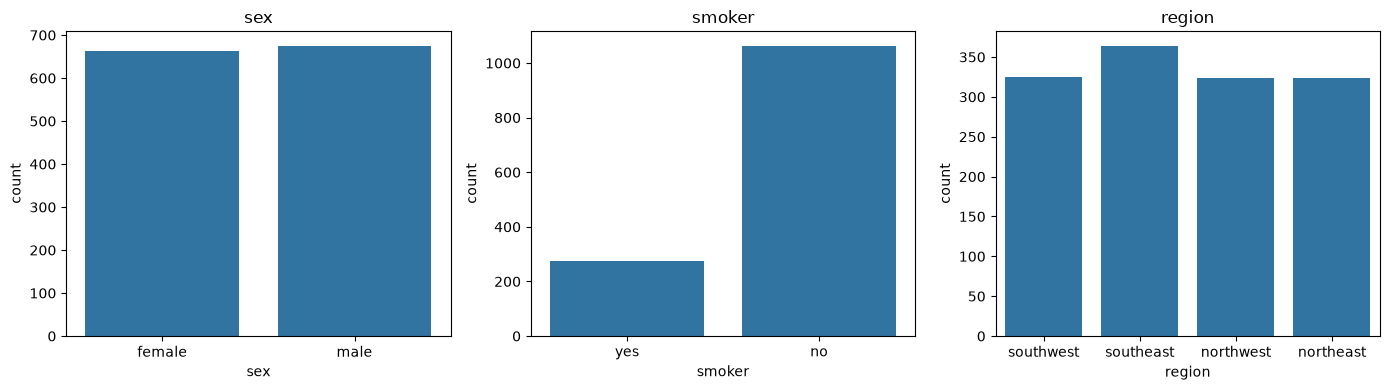

In [167]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["sex", "smoker", "region"]):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**What this tells me:** sex and region are balanced; smoker is imbalanced (about 80/20).

---

### Part 3: Bivariate Analysis (Day 5)

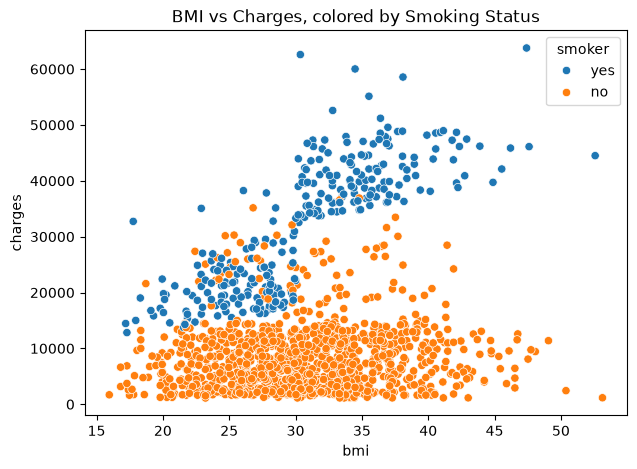

In [168]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")
plt.title("BMI vs Charges, colored by Smoking Status")
plt.show()

**What this shows:** non-smokers stay in a low, tight band regardless of BMI. Smokers spread across a much wider, higher range - and the highest charges of all belong to smokers with high BMI too.

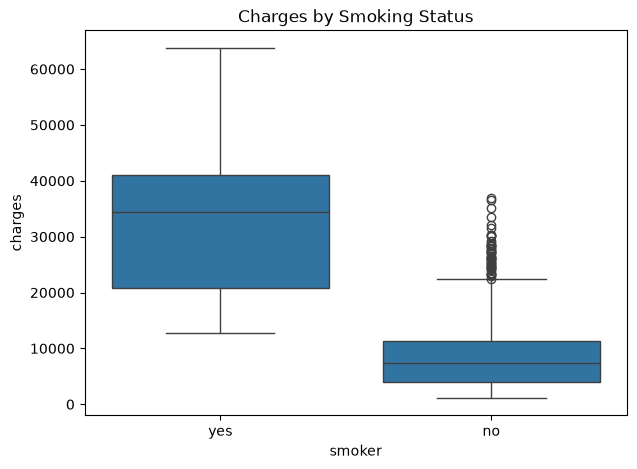

In [169]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="smoker", y="charges")
plt.title("Charges by Smoking Status")
plt.show()

**What this shows:** almost no overlap between the two boxes - smokers' charges sit far above non-smokers' across the board.

---

### Part 4: Correlation Analysis


In [170]:
corr = df.corr(numeric_only=True)
corr

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


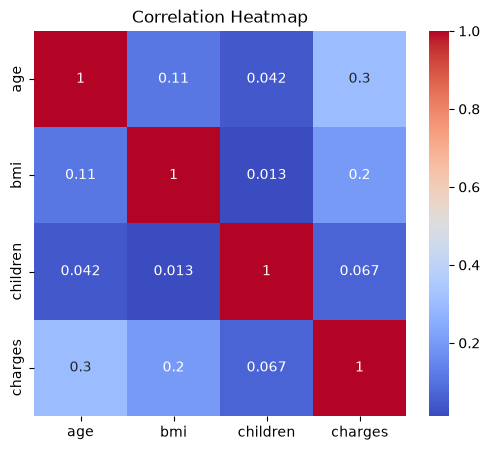

In [171]:
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**What this shows:** on their own, the numeric variables only weakly correlate with charges (age: 0.30, bmi: 0.20). That's a bit misleading, though - smoker isn't in this table because it's categorical. Once I convert it to 0/1 and check:

In [172]:
df["smoker_numeric"] = df["smoker"].map({"yes": 1, "no": 0})
print("Correlation between smoker and charges:", df["smoker_numeric"].corr(df["charges"]))

Correlation between smoker and charges: 0.7872343672800318


**This is the real story:** smoking status correlates with charges far more strongly (0.79) than any purely numeric column does.

---


### Part 5: Strongest Relationships - What They Mean for a Future Model

The three strongest relationships I found this week are:

1. **Smoker status → Charges (r ≈ 0.79):** by far the strongest 
   relationship in the dataset. Any model predicting charges needs 
   `smoker` as a feature - probably the most important one.
2. **Age → Charges (r ≈ 0.30):** a moderate relationship - older 
   patients tend to have somewhat higher charges, but it's much weaker 
   than smoking status.
3. **BMI → Charges (r ≈ 0.20):** a weak relationship on its own, but the 
   scatter plot in Part 3 suggests it matters more specifically *for 
   smokers* - high BMI smokers had the highest charges of anyone. This 
   hints that an interaction between `bmi` and `smoker` might be worth 
   testing in a future model, not just each variable separately.

Important caveat: none of this proves smoking *causes* higher charges by 
itself - insurers may price smokers higher for reasons beyond direct 
health costs. Correlation shows the relationship exists; it doesn't 
explain why.

---

### Summary - The Full Data Story

Putting the whole week together: `charges` is right-skewed (Day 1), with 
a cluster of high-cost outliers (Day 4) that turn out to be almost 
entirely smokers. Bivariate analysis (Day 5) confirmed this isn't a 
coincidence - smoking status has, by far, the strongest relationship 
with charges of any variable in the dataset (r ≈ 0.79), well beyond age 
or BMI alone. If I were building a predictive model on this data, 
`smoker` would be the first feature I'd make sure was included.